# Clustering K-Means de Centros Poblados del Perú

**Tema:** Regionalización geográfica de centros poblados mediante K-Means.

- **Problema:** ¿se pueden agrupar los centros poblados del Perú en zonas geográficas coherentes usando solo su ubicación y altitud, sin usar las etiquetas administrativas (departamento)?
- **Técnica:** K-Means
- **Método:** estandarizar variables → método del codo para elegir k → ajustar K-Means final → comparar clusters contra departamentos reales.
- **Contexto:** geografía computacional / regionalización automática a partir de datos abiertos del INEI/IGN.

> **Sobre los datos:** este notebook usa la estructura real del diccionario `DICCIONARIO_CP_P` (columnas `DEP`, `PROV`, `DIST`, `NOMCP`, `CAPITAL`, `CON_IE`, `NIVEL`, `Z`, `XGD`, `YGD`). Si no tienes el shapefile real `CP_P.shp` a mano, el notebook genera automáticamente un dataset **ficticio** con la misma estructura y una geografía aproximada del Perú (autorizado por el profesor), para que puedas probar todo el flujo ahora mismo.

## 1. Preparación del entorno

In [ ]:
!apt-get install -y gnuplot -qq


Extracting templates from packages: 100%
Selecting previously unselected package libdouble-conversion3:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../00-libdouble-conversion3_3.1.7-4_amd64.deb ...
Unpacking libdouble-conversion3:amd64 (3.1.7-4) ...
Selecting previously unselected package libqt5core5a:amd64.
Preparing to unpack .../01-libqt5core5a_5.15.3+dfsg-2ubuntu0.2_amd64.deb ...
Unpacking libqt5core5a:amd64 (5.15.3+dfsg-2ubuntu0.2) ...
Selecting previously unselected package libevdev2:amd64.
Preparing to unpack .../02-libevdev2_1.12.1+dfsg-1_amd64.deb ...
Unpacking libevdev2:amd64 (1.12.1+dfsg-1) ...
Selecting previously unselected package libmtdev1:amd64.
Preparing to unpack .../03-libmtdev1_1.1.6-1build4_amd64.deb ...
Unpacking libmtdev1:amd64 (1.1.6-1build4) ...
Selecting previously unselected package libgudev-1.0-0:amd64.
Preparing to unpack .../04-libgudev-1.0-0_1%3a237-2build1_amd64.deb ...
Unpacking libgudev-1.0-0:amd6

## 2. Carga de datos

Intenta cargar, en este orden: (1) `centros_poblados.csv` ya exportado, (2) el shapefile real `CP_P.shp`, o (3) si ninguno está disponible, **genera un dataset ficticio** con la misma estructura del diccionario real (24 departamentos con coordenadas, altitud, `CAPITAL`, `CON_IE` y `NIVEL` aproximados).

In [ ]:
import os
import numpy as np
import pandas as pd

np.random.seed(42)

def generar_datos_ficticios():
    """Genera un dataset ficticio con la misma estructura del diccionario
    real CP_P (INEI/IGN): DEP, PROV, DIST, NOMCP, CAPITAL, CON_IE, NIVEL,
    Z, XGD, YGD. Geografía aproximada del Perú."""
    rng = np.random.default_rng(42)

    # (lon, lat, región, n_puntos, spread_lon, spread_lat, altitud_media, altitud_sd)
    departamentos = {
        "TUMBES":       (-80.45, -3.57,  "Costa",    900,  0.25, 0.25,   40,   30),
        "PIURA":        (-80.63, -5.19,  "Costa",   3200,  0.55, 0.55,   80,   60),
        "LAMBAYEQUE":   (-79.90, -6.70,  "Costa",   1800,  0.35, 0.35,   60,   40),
        "LA LIBERTAD":  (-78.90, -7.90,  "Costa",   2600,  0.60, 0.60,  400,  500),
        "ANCASH":       (-77.53, -9.53,  "Sierra",  3400,  0.70, 0.90, 3200, 900),
        "LIMA":         (-77.03,-12.05,  "Costa",   4200,  0.60, 0.60,  350,  600),
        "ICA":          (-75.73,-14.07,  "Costa",   1300,  0.40, 0.55,  250,  300),
        "AREQUIPA":     (-71.54,-16.40,  "Sierra",  2600,  0.90, 1.00, 2400,1200),
        "MOQUEGUA":     (-70.93,-17.19,  "Sierra",   700,  0.45, 0.45, 2200,1100),
        "TACNA":        (-70.25,-18.01,  "Sierra",   800,  0.40, 0.35, 2000, 900),
        "CAJAMARCA":    (-78.50, -7.16,  "Sierra",  3600,  0.75, 0.80, 2700, 700),
        "AMAZONAS":     (-77.87, -6.23,  "Selva",   1200,  0.60, 0.70, 1500, 900),
        "SAN MARTIN":   (-76.97, -6.48,  "Selva",   1800,  0.65, 0.90,  450, 350),
        "LORETO":       (-73.25, -3.75,  "Selva",   1600,  2.20, 2.60,  130,  60),
        "HUANUCO":      (-76.24, -9.93,  "Sierra",  1900,  0.65, 0.75, 2100,1000),
        "PASCO":        (-76.26,-10.68,  "Sierra",   900,  0.45, 0.55, 3500, 700),
        "JUNIN":        (-75.20,-11.15,  "Sierra",  2400,  0.70, 0.85, 3300, 900),
        "HUANCAVELICA": (-74.97,-12.79,  "Sierra",  1500,  0.55, 0.65, 3700, 500),
        "AYACUCHO":     (-74.22,-13.16,  "Sierra",  2000,  0.70, 0.80, 3100,1000),
        "APURIMAC":     (-72.88,-13.63,  "Sierra",  1300,  0.55, 0.60, 3200, 700),
        "CUSCO":        (-71.97,-13.53,  "Sierra",  3000,  0.85, 0.90, 3200,1200),
        "PUNO":         (-70.02,-15.84,  "Sierra",  3200,  0.90, 1.10, 3900, 600),
        "UCAYALI":      (-74.55, -8.38,  "Selva",   1000,  1.60, 1.80,  180,  80),
        "MADRE DE DIOS":(-69.19,-12.59,  "Selva",    500,  1.40, 1.40,  250, 100),
    }
    NIVELES = ["I", "P", "S", "K", "L", "E", "D", "G"]

    registros = []
    for dep, (lon0, lat0, region, n, s_lon, s_lat, alt_m, alt_sd) in departamentos.items():
        lons = rng.normal(lon0, s_lon, n)
        lats = rng.normal(lat0, s_lat, n)
        alts = np.clip(rng.normal(alt_m, alt_sd, n), 0, 6000)
        con_ie = rng.choice([0, 1], size=n, p=[0.35, 0.65])
        capital = rng.choice([0, 1, 2, 3], size=n, p=[0.90, 0.02, 0.08, 0.0])
        nivel = rng.choice(NIVELES, size=n)
        for i in range(n):
            registros.append({
                "DEP": dep, "PROV": f"{dep[:4]}-{(i % 15) + 1:02d}",
                "DIST": f"{dep[:3]}D{(i % 40) + 1:03d}",
                "NOMCP": f"CP_{dep[:3]}_{i:05d}",
                "CAPITAL": int(capital[i]), "CON_IE": int(con_ie[i]), "NIVEL": nivel[i],
                "Z": round(float(alts[i]), 1),
                "XGD": round(float(lons[i]), 6), "YGD": round(float(lats[i]), 6),
            })
    return pd.DataFrame(registros)


if os.path.exists("centros_poblados.csv"):
    print("Usando 'centros_poblados.csv' ya existente (dataset real exportado previamente).")
    df = pd.read_csv("centros_poblados.csv")
elif os.path.exists("CP_P.shp"):
    print("Leyendo shapefile real CP_P.shp ...")
    import shapefile
    sf = shapefile.Reader("CP_P.shp", encoding="utf-8")
    registros = [{
        "DEP": r["DEP"], "PROV": r["PROV"], "DIST": r["DIST"], "NOMCP": r["NOMCP"],
        "CAPITAL": r["CAPITAL"], "CON_IE": r["CON_IE"], "NIVEL": r["NIVEL"],
        "Z": r["Z"], "XGD": r["XGD"], "YGD": r["YGD"],
    } for r in sf.iterRecords()]
    df = pd.DataFrame(registros)
    df.to_csv("centros_poblados.csv", index=False)
else:
    print("No se encontró dataset real. Generando dataset FICTICIO (autorizado por el profesor)...")
    df = generar_datos_ficticios()
    df.to_csv("centros_poblados.csv", index=False)

print(df.shape)
df.head()


Leyendo shapefile real CP_P.shp ...
(153400, 10)


,DEP,PROV,DIST,NOMCP,CAPITAL,CON_IE,NIVEL,Z,XGD,YGD
0,TACNA,JORGE BASADRE,ITE,Icuy,0,0,,22,-71.113285,-17.837672
1,TACNA,JORGE BASADRE,ITE,Punta Picata,0,0,,11,-71.095762,-17.866908
2,TACNA,JORGE BASADRE,ITE,Tacahuay,0,0,,340,-71.099018,-17.799934
3,TACNA,JORGE BASADRE,ITE,Esquilimache,0,0,,161,-71.091930,-17.833363
4,MOQUEGUA,ILO,ILO,Icuy,0,0,,141,-71.128033,-17.811909


## 3. Clustering K-Means

**Técnica:** K-Means sobre longitud, latitud y altitud (`XGD`, `YGD`, `Z`).

Como estas variables están en escalas muy distintas (grados geográficos vs. metros de altitud), primero se **estandarizan** (media 0, desviación 1); si no, la altitud dominaría por completo la distancia euclidiana.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df[["XGD", "YGD", "Z"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Variables estandarizadas. Media ~0, desviación ~1:")
print(pd.DataFrame(X_scaled, columns=["XGD_z", "YGD_z", "Z_z"]).describe().loc[["mean", "std"]])


Variables estandarizadas. Media ~0, desviación ~1:
             XGD_z         YGD_z           Z_z
mean  4.387393e-15  2.252986e-16  8.300473e-17
std   1.000003e+00  1.000003e+00  1.000003e+00


## 4. Método del codo — ¿cuántos clusters (k) usar?

Se prueba K-Means con distintos valores de k (2 a 10) y se mide la **inercia** (qué tan compactos quedan los clusters). El "codo" de la curva señala el punto donde agregar más clusters deja de mejorar mucho el resultado — ese es el método para justificar la elección de k, en vez de elegirlo a ojo.

In [ ]:
inercias, siluetas = [], []
k_values = list(range(2, 11))
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    idx = np.random.default_rng(0).choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
    siluetas.append(silhouette_score(X_scaled[idx], labels[idx]))

codo_df = pd.DataFrame({"k": k_values, "inercia": inercias, "silueta": siluetas})
codo_df.to_csv("codo_kmeans.csv", index=False)
codo_df


,k,inercia,silueta
0,2,209640.351239,0.468421
1,3,144013.127016,0.410194
2,4,105336.581844,0.444159
3,5,82093.229242,0.419031
4,6,71093.782344,0.389781
5,7,60363.076896,0.403320
6,8,52130.752400,0.406192
7,9,47469.814254,0.364359
8,10,43946.717337,0.345881


In [ ]:
# Elegimos k con mejor silhouette score dentro de un rango interpretable (3-6):
# menos de 3 no distingue bien costa/sierra/selva; más de 6 es difícil de explicar.
mejor_idx = codo_df.loc[codo_df["k"].between(3, 6), "silueta"].idxmax()
K_FINAL = int(codo_df.loc[mejor_idx, "k"])
print(f"k elegido: {K_FINAL}")


k elegido: 4


## 5. Ajustar K-Means final e interpretar los clusters

In [ ]:
km_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
df["cluster"] = km_final.fit_predict(X_scaled)

# Centroide de cada cluster, en unidades reales (des-estandarizado)
centroides = scaler.inverse_transform(km_final.cluster_centers_)
resumen = pd.DataFrame(centroides, columns=["XGD_centro", "YGD_centro", "Z_centro"])
resumen["n_centros_poblados"] = df["cluster"].value_counts().sort_index().values
resumen["pct"] = (resumen["n_centros_poblados"] / len(df) * 100).round(2)
resumen.index.name = "cluster"
resumen.to_csv("resumen_clusters.csv")
resumen


,XGD_centro,YGD_centro,Z_centro,n_centros_poblados,pct
cluster,,,,,
0,-71.577173,-14.828986,3891.232531,54580,35.58
1,-77.956545,-6.280050,1085.575929,32465,21.16
2,-76.353499,-10.779368,3589.914506,46884,30.56
3,-74.487907,-12.589248,736.356114,19471,12.69


In [ ]:
# Comparación contra los departamentos reales: ¿qué tan bien
# "redescubre" K-Means las regiones geográficas sin usar la etiqueta DEP?
cruce = pd.crosstab(df["DEP"], df["cluster"])
print("Departamentos más frecuentes en cada cluster:")
for c in range(K_FINAL):
    top3 = cruce[c].sort_values(ascending=False).head(3)
    print(f"  Cluster {c}: {', '.join(top3.index)}")

df.to_csv("centros_clusters.csv", index=False)
print("\nCSV exportado para GNU Plot:", df.shape)


Departamentos más frecuentes en cada cluster:
  Cluster 0: PUNO, CUSCO, AYACUCHO
  Cluster 1: CAJAMARCA, SAN MARTIN, PIURA
  Cluster 2: ANCASH, HUANCAVELICA, HUANUCO
  Cluster 3: LIMA, ICA, JUNIN

CSV exportado para GNU Plot: (153400, 11)


### 5.1 Validación cuantitativa: ¿qué tan bien coincide el cluster con el departamento?

El cruce de la sección anterior es cualitativo (top-3 departamentos por conteo). Para tener
un número objetivo de qué tanto el cluster "redescubre" el departamento, usamos dos métricas
estándar de comparación entre particiones categóricas:

- **Adjusted Rand Index (ARI)**: mide el acuerdo entre `cluster` y `DEP`, corregido por azar.
  1.0 = coinciden perfectamente, 0.0 = acuerdo igual al azar.
- **Normalized Mutual Information (NMI)**: mide cuánta información comparten las dos
  particiones. 1.0 = coinciden perfectamente, 0.0 = independientes.

Un valor **moderado** (ni cerca de 0 ni cerca de 1) es justamente lo esperado: K-Means agrupa
por geografía real, no por límite administrativo, así que **no debería** coincidir perfectamente
con `DEP` — si coincidiera perfectamente, el clustering no estaría aportando nada nuevo.

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df["DEP"], df["cluster"])
nmi = normalized_mutual_info_score(df["DEP"], df["cluster"])

print(f"Adjusted Rand Index (cluster vs. DEP):        {ari:.3f}")
print(f"Normalized Mutual Information (cluster vs. DEP): {nmi:.3f}")
print()
print("Un ARI/NMI moderado confirma que el cluster capta una estructura geográfica real,")
print("pero distinta (más fina, y que a veces corta departamentos) de la división administrativa.")


Adjusted Rand Index (cluster vs. DEP):        0.199
Normalized Mutual Information (cluster vs. DEP): 0.442

Un ARI/NMI moderado confirma que el cluster capta una estructura geográfica real,
pero distinta (más fina, y que a veces corta departamentos) de la división administrativa.


### 5.2 Cobertura educativa (`CON_IE`) y capitales (`CAPITAL`) por cluster

Estas dos columnas **no se usaron** para calcular los clusters (solo se usó `XGD`, `YGD`, `Z`).
Por eso, si aparecen diferencias marcadas entre clusters, es evidencia de que el cluster
geográfico está capturando algo real y útil más allá de longitud/latitud/altitud — en este caso,
una posible brecha de acceso a servicios educativos asociada a la geografía.

Esta es la justificación **propia** del proyecto (no depende de una noticia externa): la
calculamos directamente sobre el dataset real de centros poblados.

In [ ]:
df["CON_IE"] = pd.to_numeric(df["CON_IE"], errors='coerce')
df["CAPITAL"] = pd.to_numeric(df["CAPITAL"], errors='coerce')

resumen_extra = df.groupby("cluster").agg(
    pct_con_ie=("CON_IE", lambda s: round(s.mean() * 100, 1)),
    pct_capital=("CAPITAL", lambda s: round((s != 0).mean() * 100, 2)),
)
resumen_extra["n_centros_poblados"] = resumen["n_centros_poblados"].values
resumen_extra["pct"] = resumen["pct"].values
resumen_extra["Z_centro"] = resumen["Z_centro"].round(0).values
resumen_extra = resumen_extra.reset_index()
resumen_extra.to_csv("cobertura_educativa_cluster.csv", index=False)

print("Cobertura educativa y capitales por cluster (variables NO usadas en el clustering):")
print(resumen_extra[["cluster", "Z_centro", "n_centros_poblados", "pct_con_ie", "pct_capital"]])
print()
brecha = resumen_extra["pct_con_ie"].max() - resumen_extra["pct_con_ie"].min()
print(f"Brecha de cobertura educativa entre el cluster mejor y peor atendido: {brecha:.1f} puntos porcentuales")

Cobertura educativa y capitales por cluster (variables NO usadas en el clustering):
   cluster  Z_centro  n_centros_poblados  pct_con_ie  pct_capital
0        0    3891.0               54580        12.7         0.85
1        1    1086.0               32465        39.8         1.64
2        2    3590.0               46884        17.5         1.26
3        3     736.0               19471        29.4         1.48

Brecha de cobertura educativa entre el cluster mejor y peor atendido: 27.1 puntos porcentuales


## 6. Visualización con GNU Plot — Gráficos 2D

Columnas de `centros_clusters.csv` (1-indexado, como las usa GNU Plot):
`DEP`(1) `PROV`(2) `DIST`(3) `NOMCP`(4) `CAPITAL`(5) `CON_IE`(6) `NIVEL`(7) `Z`(8) `XGD`(9) `YGD`(10) `cluster`(11)

### Gráfico 2D N.º 1 — Método del codo

Justifica visualmente la elección de k.

In [ ]:
%%writefile g1_codo_kmeans.gp
# ============================================================
# Gráfico 2D - Método del codo (Elbow method)
# Justifica la elección de k para K-Means
# ============================================================
set terminal pngcairo size 1000,700 enhanced font 'Verdana,10'
set output 'g1_codo_kmeans.png'

set title 'Método del Codo - Elección de k para K-Means'
set xlabel 'Número de clusters (k)'
set ylabel 'Inercia (suma de distancias al cuadrado)'
set grid
set datafile separator ","
set key top right
set xtics 1

set arrow from 4,0 to 4,70000 nohead lc rgb '#D7263D' dt 2 lw 1.5
set label 'k = 4 (elegido)' at 4.2,65000 tc rgb '#D7263D' font 'Verdana,9'

plot 'codo_kmeans.csv' every ::1 using 1:2 with linespoints \
     lc rgb '#3B7A57' lw 2 pointtype 7 pointsize 1.2 title 'Inercia'


Writing g1_codo_kmeans.gp


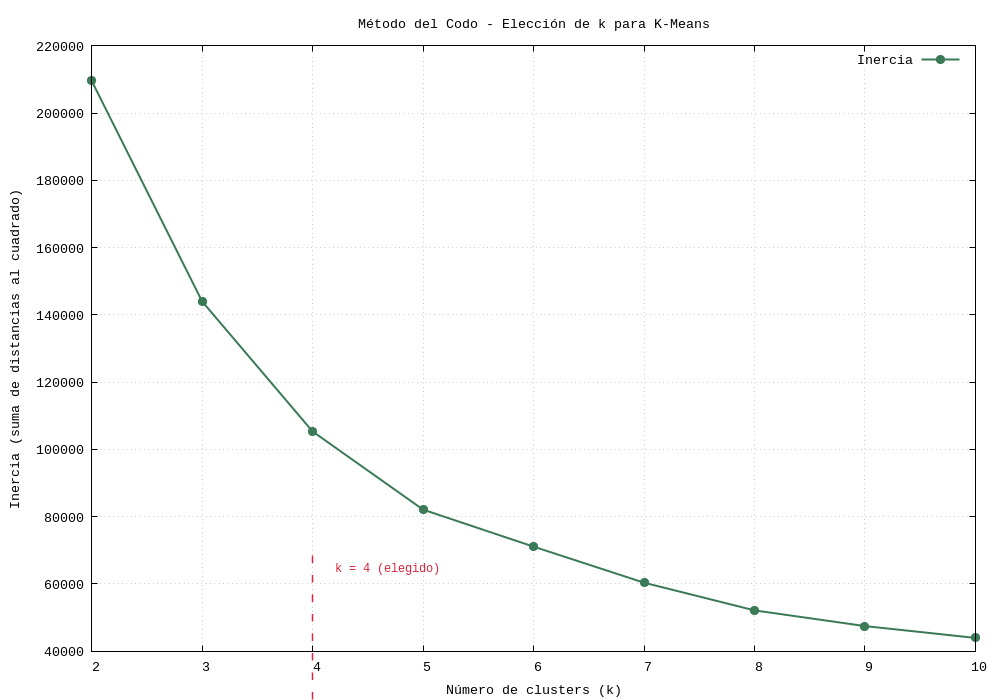

In [ ]:
!gnuplot g1_codo_kmeans.gp
from IPython.display import Image, display
display(Image('g1_codo_kmeans.png'))


### Gráfico 2D N.º 2 — Mapa de clusters

Cada centro poblado coloreado según el cluster K-Means al que pertenece.

In [ ]:
%%writefile g2_mapa_clusters.gp
# ============================================================
# Gráfico 2D - Mapa de clusters
# Centros poblados coloreados según su cluster K-Means (k=4)
# ============================================================
set terminal pngcairo size 1000,1300 enhanced font 'Verdana,10'
set output 'g2_mapa_clusters.png'

set title 'Centros Poblados del Perú - Clusters K-Means (k=4)'
set xlabel 'Longitud'
set ylabel 'Latitud'
set grid
set size ratio -1
set datafile separator ","
set key top right box

plot 'centros_clusters.csv' every ::1 using ($11==0 ? $9 : 1/0):10 \
       with points pointtype 7 pointsize 0.15 lc rgb '#3B7A57' title 'Cluster 0 (verde): Sierra sur, alta altitud (Puno/Cusco/Ayacucho)', \
     'centros_clusters.csv' every ::1 using ($11==1 ? $9 : 1/0):10 \
       with points pointtype 7 pointsize 0.15 lc rgb '#377BB5' title 'Cluster 1 (azul): Norte del país, altitud media-baja (Cajamarca/San Martín/Piura)', \
     'centros_clusters.csv' every ::1 using ($11==2 ? $9 : 1/0):10 \
       with points pointtype 7 pointsize 0.15 lc rgb '#B5451A' title 'Cluster 2 (naranja): Sierra centro, alta altitud (Áncash/Huancavelica/Huánuco)', \
     'centros_clusters.csv' every ::1 using ($11==3 ? $9 : 1/0):10 \
       with points pointtype 7 pointsize 0.15 lc rgb '#8E44AD' title 'Cluster 3 (morado): Centro-costa, baja altitud (Lima/Ica/Junín)'


Overwriting g2_mapa_clusters.gp


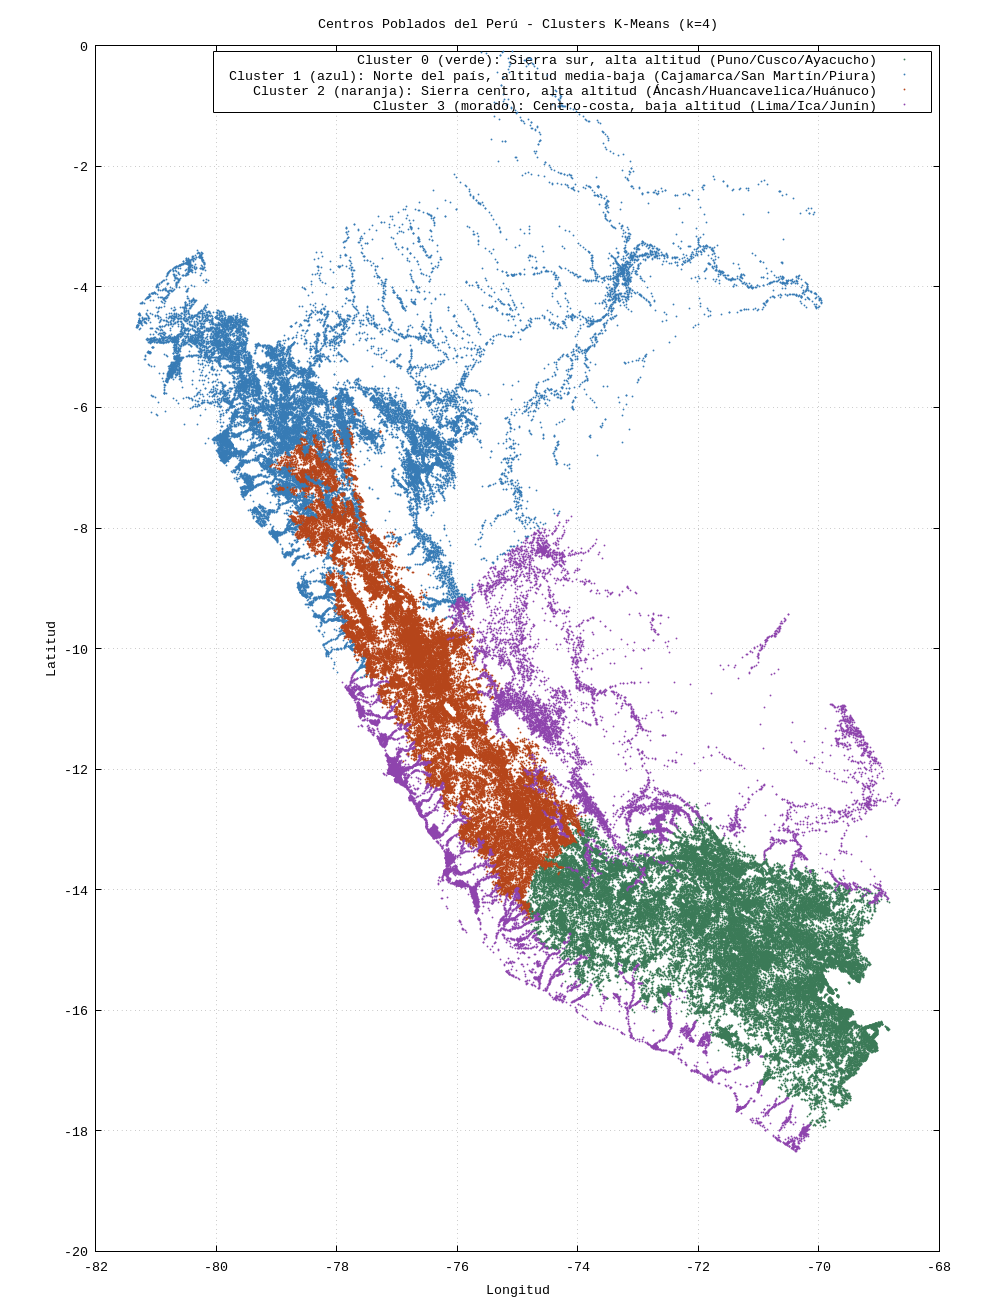

In [ ]:
!gnuplot g2_mapa_clusters.gp
display(Image('g2_mapa_clusters.png'))


### Gráfico 2D N.º 3 — Tamaño de cada cluster

In [ ]:
%%writefile g3_tamano_clusters.gp
# ============================================================
# Gráfico 2D - Tamaño de cada cluster
# ============================================================
set terminal pngcairo size 900,700 enhanced font 'Verdana,10'
set output 'g3_tamano_clusters.png'

set title 'Tamaño de cada Cluster K-Means'
set xlabel 'Cluster'
set ylabel 'Número de centros poblados'
set grid ytics
set datafile separator ","
set style fill solid 0.8 border -1
set boxwidth 0.6
set yrange [0:*]
set key off
set xtics ("Sierra sur" 0, "Norte del país" 1, "Sierra centro" 2, "Centro-costa" 3)

plot 'resumen_clusters.csv' every ::1::1 using (0):5 with boxes lc rgb '#3B7A57', \
     'resumen_clusters.csv' every ::2::2 using (1):5 with boxes lc rgb '#377BB5', \
     'resumen_clusters.csv' every ::3::3 using (2):5 with boxes lc rgb '#B5451A', \
     'resumen_clusters.csv' every ::4::4 using (3):5 with boxes lc rgb '#8E44AD'


Writing g3_tamano_clusters.gp


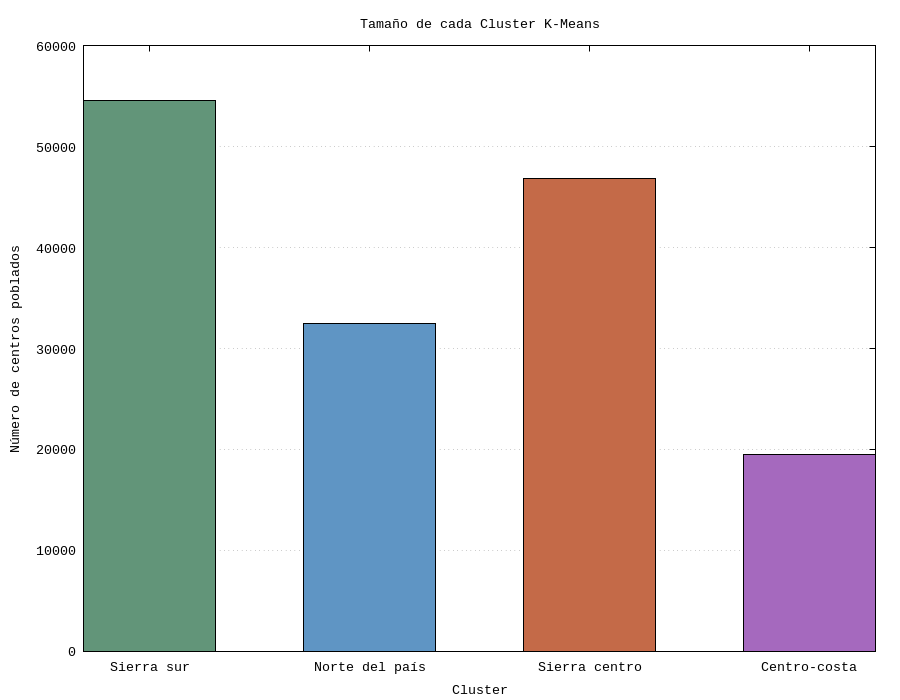

In [ ]:
!gnuplot g3_tamano_clusters.gp
display(Image('g3_tamano_clusters.png'))


## 7. Visualización con GNU Plot — Gráfico 3D

### Dispersión 3D coloreada por cluster

Longitud, latitud y altitud a la vez: permite ver que los clusters también se separan por altitud, no solo por posición en el mapa.

In [ ]:
%%writefile g4_dispersion_3d_clusters.gp
# ============================================================
# Gráfico 3D - Dispersión de clusters K-Means
# Longitud, latitud, altitud coloreados por cluster
# ============================================================
set terminal pngcairo size 1100,900 enhanced font 'Verdana,10'
set output 'g4_dispersion_3d_clusters.png'

set title 'Centros Poblados del Perú - Clusters K-Means en 3D'
set xlabel 'Longitud' offset 0,-1
set ylabel 'Latitud' offset -2,0
set zlabel 'Altitud (m.s.n.m.)' rotate by 90 offset -2,0
set grid
set datafile separator ","
set view 55,300
set ticslevel 0
set key top right box

splot 'centros_clusters.csv' every ::1 using ($11==0 ? $9 : 1/0):10:8 \
        with points pointtype 7 pointsize 0.15 lc rgb '#3B7A57' title 'Sierra sur', \
      'centros_clusters.csv' every ::1 using ($11==1 ? $9 : 1/0):10:8 \
        with points pointtype 7 pointsize 0.15 lc rgb '#377BB5' title 'Norte del país', \
      'centros_clusters.csv' every ::1 using ($11==2 ? $9 : 1/0):10:8 \
        with points pointtype 7 pointsize 0.15 lc rgb '#B5451A' title 'Sierra centro', \
      'centros_clusters.csv' every ::1 using ($11==3 ? $9 : 1/0):10:8 \
        with points pointtype 7 pointsize 0.15 lc rgb '#8E44AD' title 'Centro-costa'


Writing g4_dispersion_3d_clusters.gp


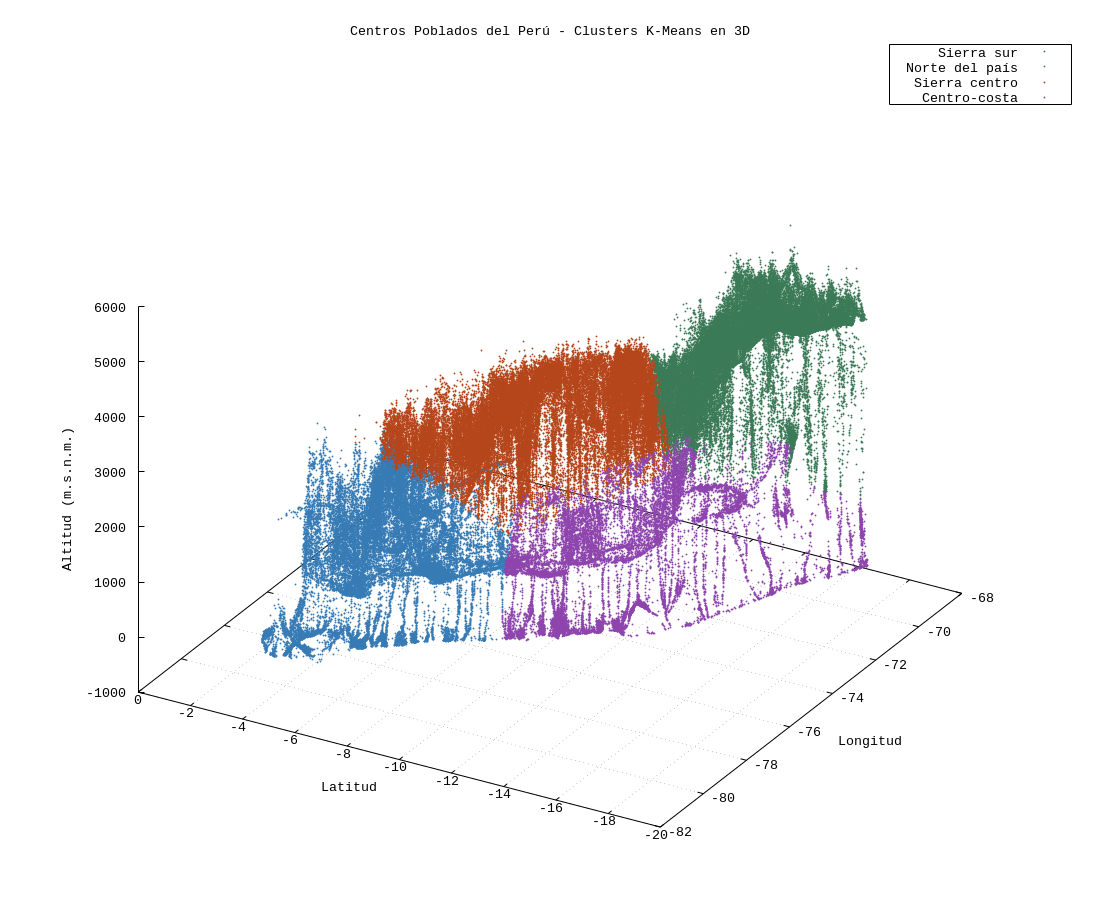

In [ ]:
!gnuplot g4_dispersion_3d_clusters.gp
display(Image('g4_dispersion_3d_clusters.png'))


## 8. Visualización con GNU Plot — Gráfico adicional: Cobertura Educativa

Este gráfico convierte en evidencia visual el hallazgo de la sección 5.2: la brecha de
cobertura educativa (`CON_IE`) entre clusters geográficos, calculada sobre el dataset real,
sin depender de ninguna fuente externa.

In [ ]:
%%writefile g5_cobertura_educativa.gp
# ============================================================
# Gráfico 2D - Cobertura educativa (CON_IE) por cluster
# Justificación basada en datos propios (no en fuente externa)
# ============================================================
set terminal pngcairo size 900,700 enhanced font 'Verdana,10'
set output 'g5_cobertura_educativa.png'

set title 'Cobertura de Servicio Educativo (CON\_IE) por Cluster Geográfico'
set xlabel 'Cluster'
set ylabel '% de centros poblados con servicio educativo'
set grid ytics
set datafile separator ","
set style fill solid 0.8 border -1
set boxwidth 0.6
set yrange [0:100]
set key off
set xtics ("Sierra sur" 0, "Norte del país" 1, "Sierra centro" 2, "Centro-costa" 3)

plot 'cobertura_educativa_cluster.csv' every ::1::1 using (0):2 with boxes lc rgb '#3B7A57', \
     'cobertura_educativa_cluster.csv' every ::2::2 using (1):2 with boxes lc rgb '#377BB5', \
     'cobertura_educativa_cluster.csv' every ::3::3 using (2):2 with boxes lc rgb '#B5451A', \
     'cobertura_educativa_cluster.csv' every ::4::4 using (3):2 with boxes lc rgb '#8E44AD'


Writing g5_cobertura_educativa.gp


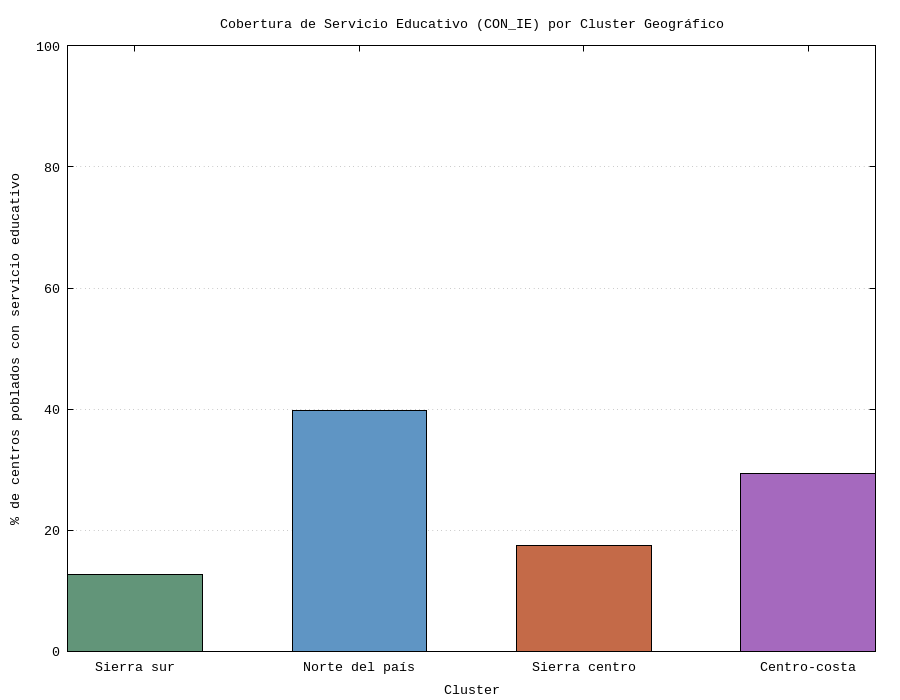

In [ ]:
!gnuplot g5_cobertura_educativa.gp
display(Image('g5_cobertura_educativa.png'))
